# 02 · Location features from OpenStreetMap

## The question this notebook answers

We already know *which borough* each listing is in. But "Camden" covers everything
from a flat above Camden Town station to a quiet street 20 minutes' walk from any
Tube. **Does knowing the exact spot — not just the borough — help predict price?**

To find out we build a handful of features that describe a location, add them to a
simple model, and check whether the model gets meaningfully better. If it doesn't,
we've learned the borough label already captures most of "location" and we can
keep the model simpler.

## The features, and why each one might matter

| Feature | Plain meaning | Why it could move price |
|---|---|---|
| `dist_station_m` | metres to nearest rail/Tube/DLR station | Guests get around London by Tube; a short walk to one is a genuine selling point |
| `stations_within_1km` | how many stations are close | More stations = more places you can get to easily |
| `dist_center_m` | metres to Charing Cross (the traditional centre) | Blunt proxy for "central / touristy" |
| `dist_restaurant_m`, `food_within_500m` | nearest, and count within 500 m, of restaurants/cafes/pubs/bars | A lively neighbourhood is worth more to a visitor |
| `dist_park_m` | metres to nearest green space (0 if inside) | Some guests value being near a park |

We **leave out** schools and doctors' surgeries. For someone renting for a year those
are important; for someone staying four nights they're irrelevant, so adding them would
just be noise. Picking features that fit the actual problem is part of the job.

## One idea you need first: coordinate reference systems

A latitude/longitude pair is an *angle*, in degrees, on a globe. You can't measure
distance with ordinary flat geometry on angles: near London, 1° of longitude is about
43 km on the ground, but 1° of latitude is about 111 km. Same number of degrees,
different real distance — so Pythagoras on raw lat/long gives nonsense.

The fix is to **project** the coordinates onto a flat grid measured in metres. The UK's
standard grid is the *British National Grid* (`EPSG:27700`). Across an area the size of
London, straight-line distance on that grid is accurate to well under 1% — fine for us.
Every distance in this notebook is computed that way, inside `londonrent.geo`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from londonrent.data import build_interim
from londonrent.geo import fetch_pois, add_location_features, LOCATION_FEATURES

df = build_interim()

# Apply the Week-1 decisions so this notebook works on the same data the model will.
df = df[df["price"].between(10, 1000)]
df = df[df["room_type"].isin(["Entire home/apt", "Private room"])].copy()
df["log_price"] = np.log(df["price"])
print(f"{len(df):,} listings in scope")

60,648 listings in scope


## 1 · The raw ingredients: OpenStreetMap points of interest

In [2]:
# Downloaded once from OpenStreetMap's Overpass API and cached in data/external.
pois = fetch_pois()
for name, gdf in pois.items():
    print(f"{name:10s} {len(gdf):>7,} features")

stations       708 features
parks       33,230 features
food        28,753 features


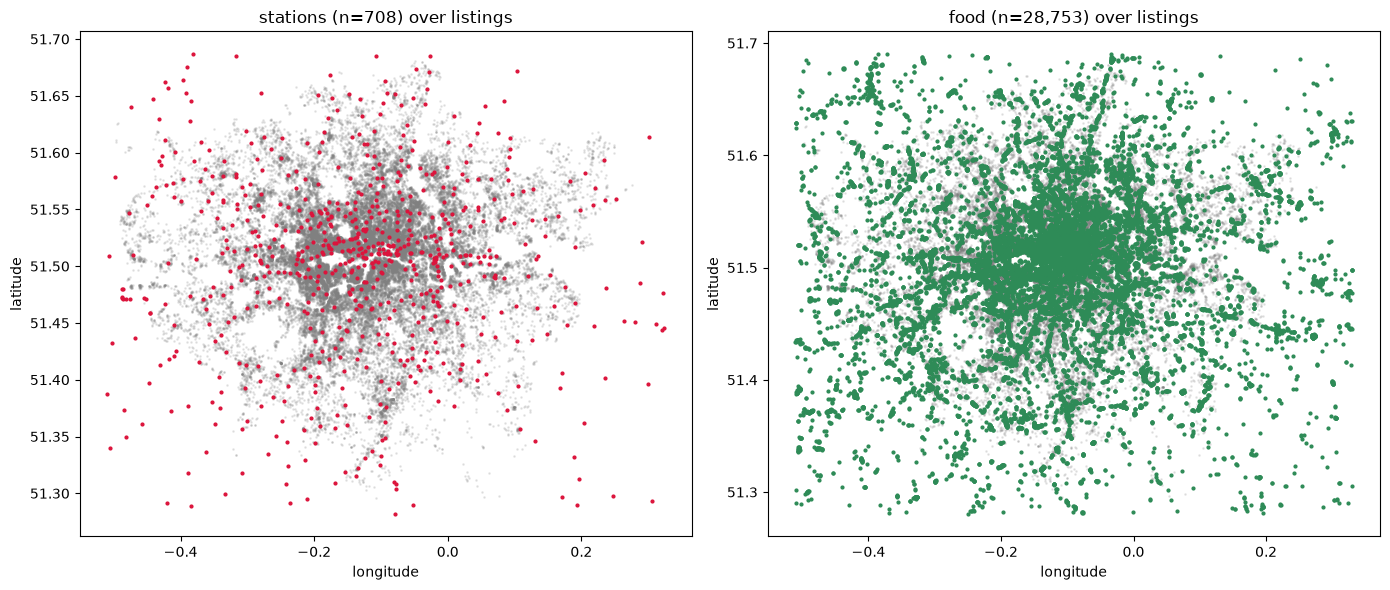

In [3]:
# Sanity-check by eye: stations should trace the Tube map, food should cluster in the centre.
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for a, key, colour in zip(ax, ["stations", "food"], ["crimson", "seagreen"]):
    ax_ = df.plot.scatter("longitude", "latitude", s=1, alpha=.15, color="grey", ax=a)
    pts = pois[key].to_crs(4326).representative_point()
    a.scatter(pts.x, pts.y, s=4, color=colour)
    a.set_title(f"{key} (n={len(pois[key]):,}) over listings")
plt.tight_layout()

## 2 · Build the features and look at them

In [4]:
df = add_location_features(df, pois)
df[LOCATION_FEATURES].describe(percentiles=[.1, .5, .9]).round(0)

,dist_station_m,stations_within_1km,dist_restaurant_m,food_within_500m,dist_park_m,dist_center_m
count,60648.0,60648.0,60648.0,60648.0,60648.0,60648.0
mean,490.0,4.0,144.0,72.0,192.0,7744.0
std,371.0,3.0,144.0,117.0,153.0,5098.0
min,2.0,0.0,0.0,0.0,0.0,11.0
10%,149.0,1.0,19.0,3.0,46.0,2413.0
50%,404.0,3.0,99.0,38.0,152.0,6314.0
90%,933.0,9.0,333.0,157.0,392.0,15244.0
max,7380.0,17.0,1579.0,921.0,2352.0,28856.0


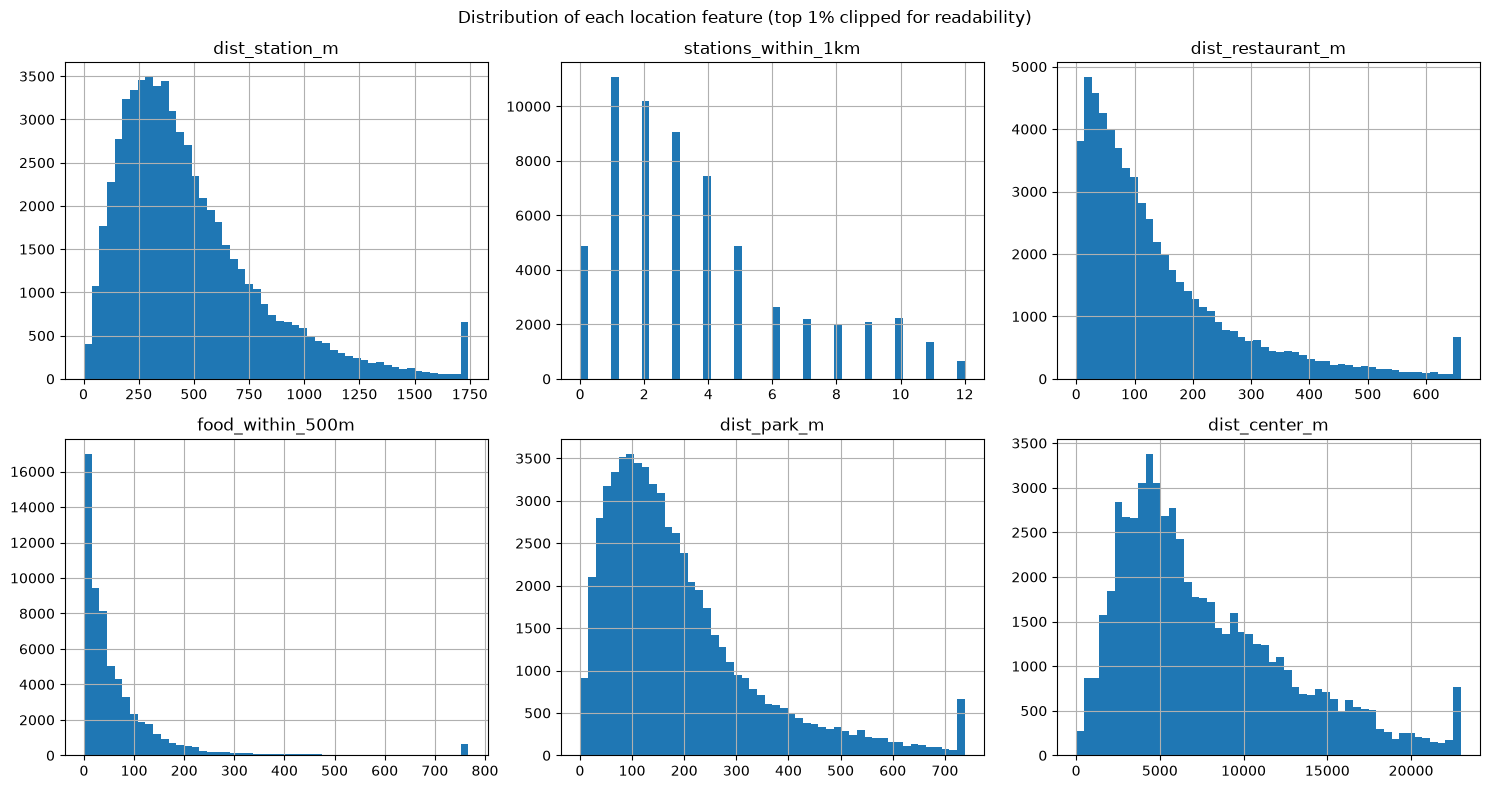

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), LOCATION_FEATURES):
    df[col].clip(upper=df[col].quantile(.99)).hist(bins=50, ax=ax)
    ax.set_title(col)
fig.suptitle("Distribution of each location feature (top 1% clipped for readability)")
plt.tight_layout()

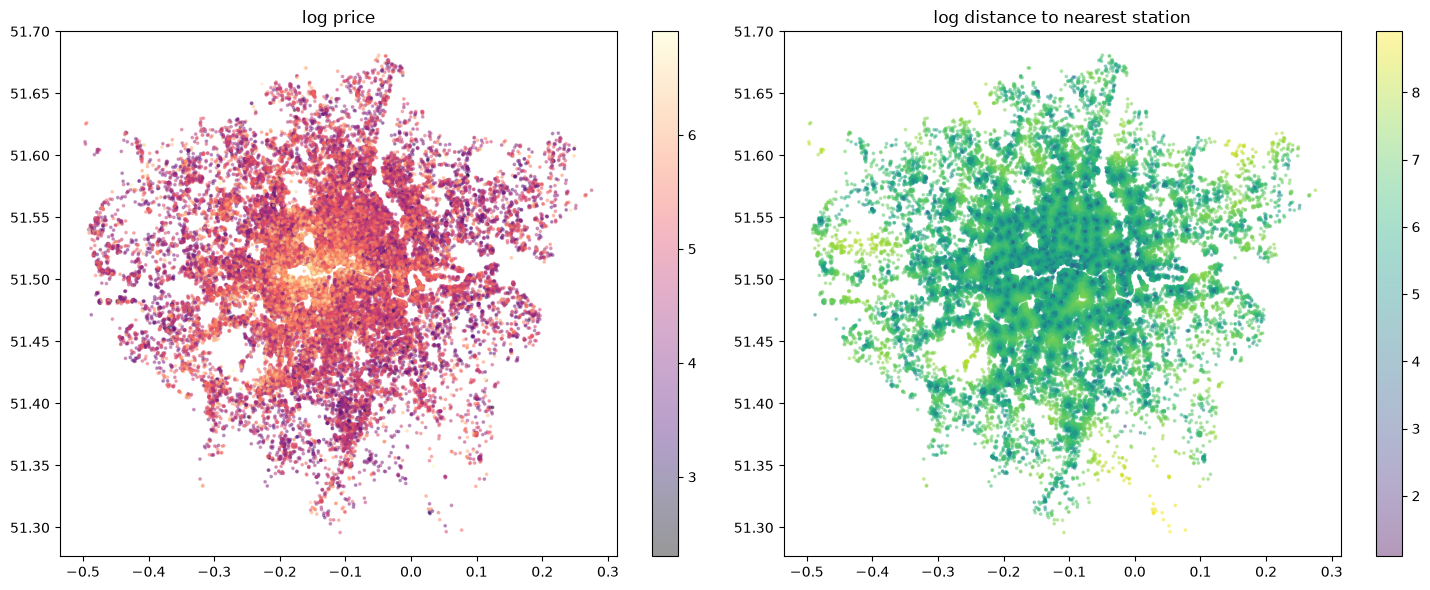

In [6]:
# The price gradient in space: darker = pricier. Expect a hot core fading outward.
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
s0 = ax[0].scatter(df["longitude"], df["latitude"], c=df["log_price"], s=3, alpha=.4, cmap="magma")
ax[0].set_title("log price"); fig.colorbar(s0, ax=ax[0])
s1 = ax[1].scatter(df["longitude"], df["latitude"], c=np.log1p(df["dist_station_m"]),
                   s=3, alpha=.4, cmap="viridis")
ax[1].set_title("log distance to nearest station"); fig.colorbar(s1, ax=ax[1])
plt.tight_layout()

### How to read the correlations below

A correlation near **0** means "no straight-line relationship with price"; near **+1** or
**-1** means a strong one. We expect *negative* signs on the distance features (further from
a station / the centre → cheaper) and *positive* on the counts. These are only
*linear* summaries — the model later can pick up curved relationships — but they're a
quick reality check that the features point the way intuition says they should.

In [7]:
corr = df[LOCATION_FEATURES + ["log_price"]].corr(numeric_only=True)["log_price"].drop("log_price")
corr.sort_values().to_frame("corr with log_price").round(3)

,corr with log_price
dist_center_m,-0.364
dist_restaurant_m,-0.244
dist_station_m,-0.208
dist_park_m,-0.182
food_within_500m,0.269
stations_within_1km,0.309


## 3 · The actual test: does location *beyond the borough* help?

This is a small controlled experiment.

* **Same model** both times: a gradient-boosted tree
  (`HistGradientBoostingRegressor` — builds many shallow trees, each correcting the
  last; a strong, low-fuss default for tabular data).
* **Same cross-validation folds** both times. *Cross-validation* = split the data into
  5 parts, train on 4, test on the held-out 1, rotate, average. It estimates how well
  the model does on listings it hasn't seen.
* **Only the feature list changes:**
  * *Baseline*: borough + room type + size (`accommodates`, `bedrooms`, `bathrooms`).
  * *+ location*: the same, plus the six OpenStreetMap features.

If the location features are pulling their weight, the error drops and R² rises.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

model = df.dropna(subset=["accommodates", "bedrooms", "bathrooms"]).copy()
y = model["log_price"].to_numpy()

cat = ["neighbourhood_cleansed", "room_type"]
size = ["accommodates", "bedrooms", "bathrooms"]

# One-hot = turn each borough/room-type label into its own 0/1 column, because the
# model needs numbers, not text. sparse_output=False returns a plain dense array,
# which HistGradientBoostingRegressor requires.
def cv_scores(feature_cols):
    pre = ColumnTransformer(
        transformers=[("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)],
        remainder="passthrough",
    )
    pipe = Pipeline([("prep", pre), ("gbr", HistGradientBoostingRegressor(random_state=0))])
    folds = KFold(n_splits=5, shuffle=True, random_state=0)
    pred_log = cross_val_predict(pipe, model[feature_cols], y, cv=folds)
    return {
        "R2 (log)": r2_score(y, pred_log),
        "MAE (log)": mean_absolute_error(y, pred_log),
        "MAE (GBP)": mean_absolute_error(np.exp(y), np.exp(pred_log)),
    }

results = {
    "baseline: borough + room + size": cv_scores(cat + size),
    "+ location features":             cv_scores(cat + size + LOCATION_FEATURES),
}
pd.DataFrame(results).T.round(3)

,R2 (log),MAE (log),MAE (GBP)
baseline: borough + room + size,0.603,0.317,78.320
+ location features,0.644,0.297,72.936


### Interpreting the result

| Model | R² (log) | MAE (£/night) |
|---|---|---|
| baseline: borough + room type + size | 0.603 | 78.3 |
| **+ 6 location features** | **0.644** | **72.9** |

Adding the OpenStreetMap features cut the typical error by about **£5.4 a night
(≈7% lower)** and lifted R² by **0.04**. That's a modest but consistent gain, and
every feature's correlation with price points the way intuition said it would:
listings further from the centre, from a station, from food, or from a park are
cheaper; listings with more stations and more restaurants nearby are dearer.

So the answer to this notebook's question is **yes — exact location carries
signal that the borough label alone misses**, which makes sense: a borough is a
big area, and "3 minutes from the Tube" versus "20 minutes" is a real difference
that "Camden" can't express.

**Decision recorded:** keep all six location features. They're cheap to compute,
they're interpretable, and they help. The OpenStreetMap extracts are committed to the repo
(`data/external/osm_*.gpkg`, ODbL-licensed) so anyone can reproduce this without
re-querying OpenStreetMap.

The next notebook adds the listing's own attributes (property type, amenities,
review scores, host signals), tunes the model properly, and uses SHAP to explain
individual predictions — where we'll see *how* the model uses these location
features, not just that they help on average.

## Honest limitations of these features

* **Parks are measured to their centre, not their nearest edge.** A listing right next to a
  large park can show a big `dist_park_m`. A fuller version would measure to the polygon
  boundary. Noted for a possible later fix.
* **`dist_center_m` is a single point.** London has several centres (City, West End, Canary
  Wharf); one Charing Cross distance flattens that.
* **OpenStreetMap is crowd-sourced.** Coverage is excellent in central London but thins at
  the edges, so outer-borough counts may be slight undercounts.
* **Spatial autocorrelation.** Nearby listings resemble each other, so plain random-fold
  cross-validation is mildly optimistic. The modelling notebook will look at grouped /
  spatial folds.

### Week-2 exit checklist
- [x] Location features built and cached (`data/external/osm_*.gpkg`)
- [x] Correlation signs all match intuition (distances negative, counts positive)
- [x] Controlled experiment run: +0.04 R², −£5.4 MAE over the borough+size baseline
- [x] Decision recorded: keep all six features
- [x] Limitations written down (park centroids, single centre point, OSM coverage, spatial CV)